In [1]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

## Import dataset and conduct Explorative Data Analysis

In [3]:
df = pd.read_csv('dataset.csv')
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Year                                  35 non-null     object 
 1   NC Students                           35 non-null     int64  
 2   International Students                35 non-null     int64  
 3   #StudentsMajor(UG)                    35 non-null     int64  
 4   #StudentsMajor (GS)                   35 non-null     int64  
 5   #Students Business School Major(UG)   35 non-null     int64  
 6   #Students Business School Major (GS)  35 non-null     int64  
 7   #Business School Major/Program(UG)    35 non-null     int64  
 8   #Business School Major/Program (GS)   35 non-null     int64  
 9    Tuition Fees (year) $                35 non-null     object 
 10  Covid (1/0)                           35 non-null     int64  
 11   # of Covid Cases    

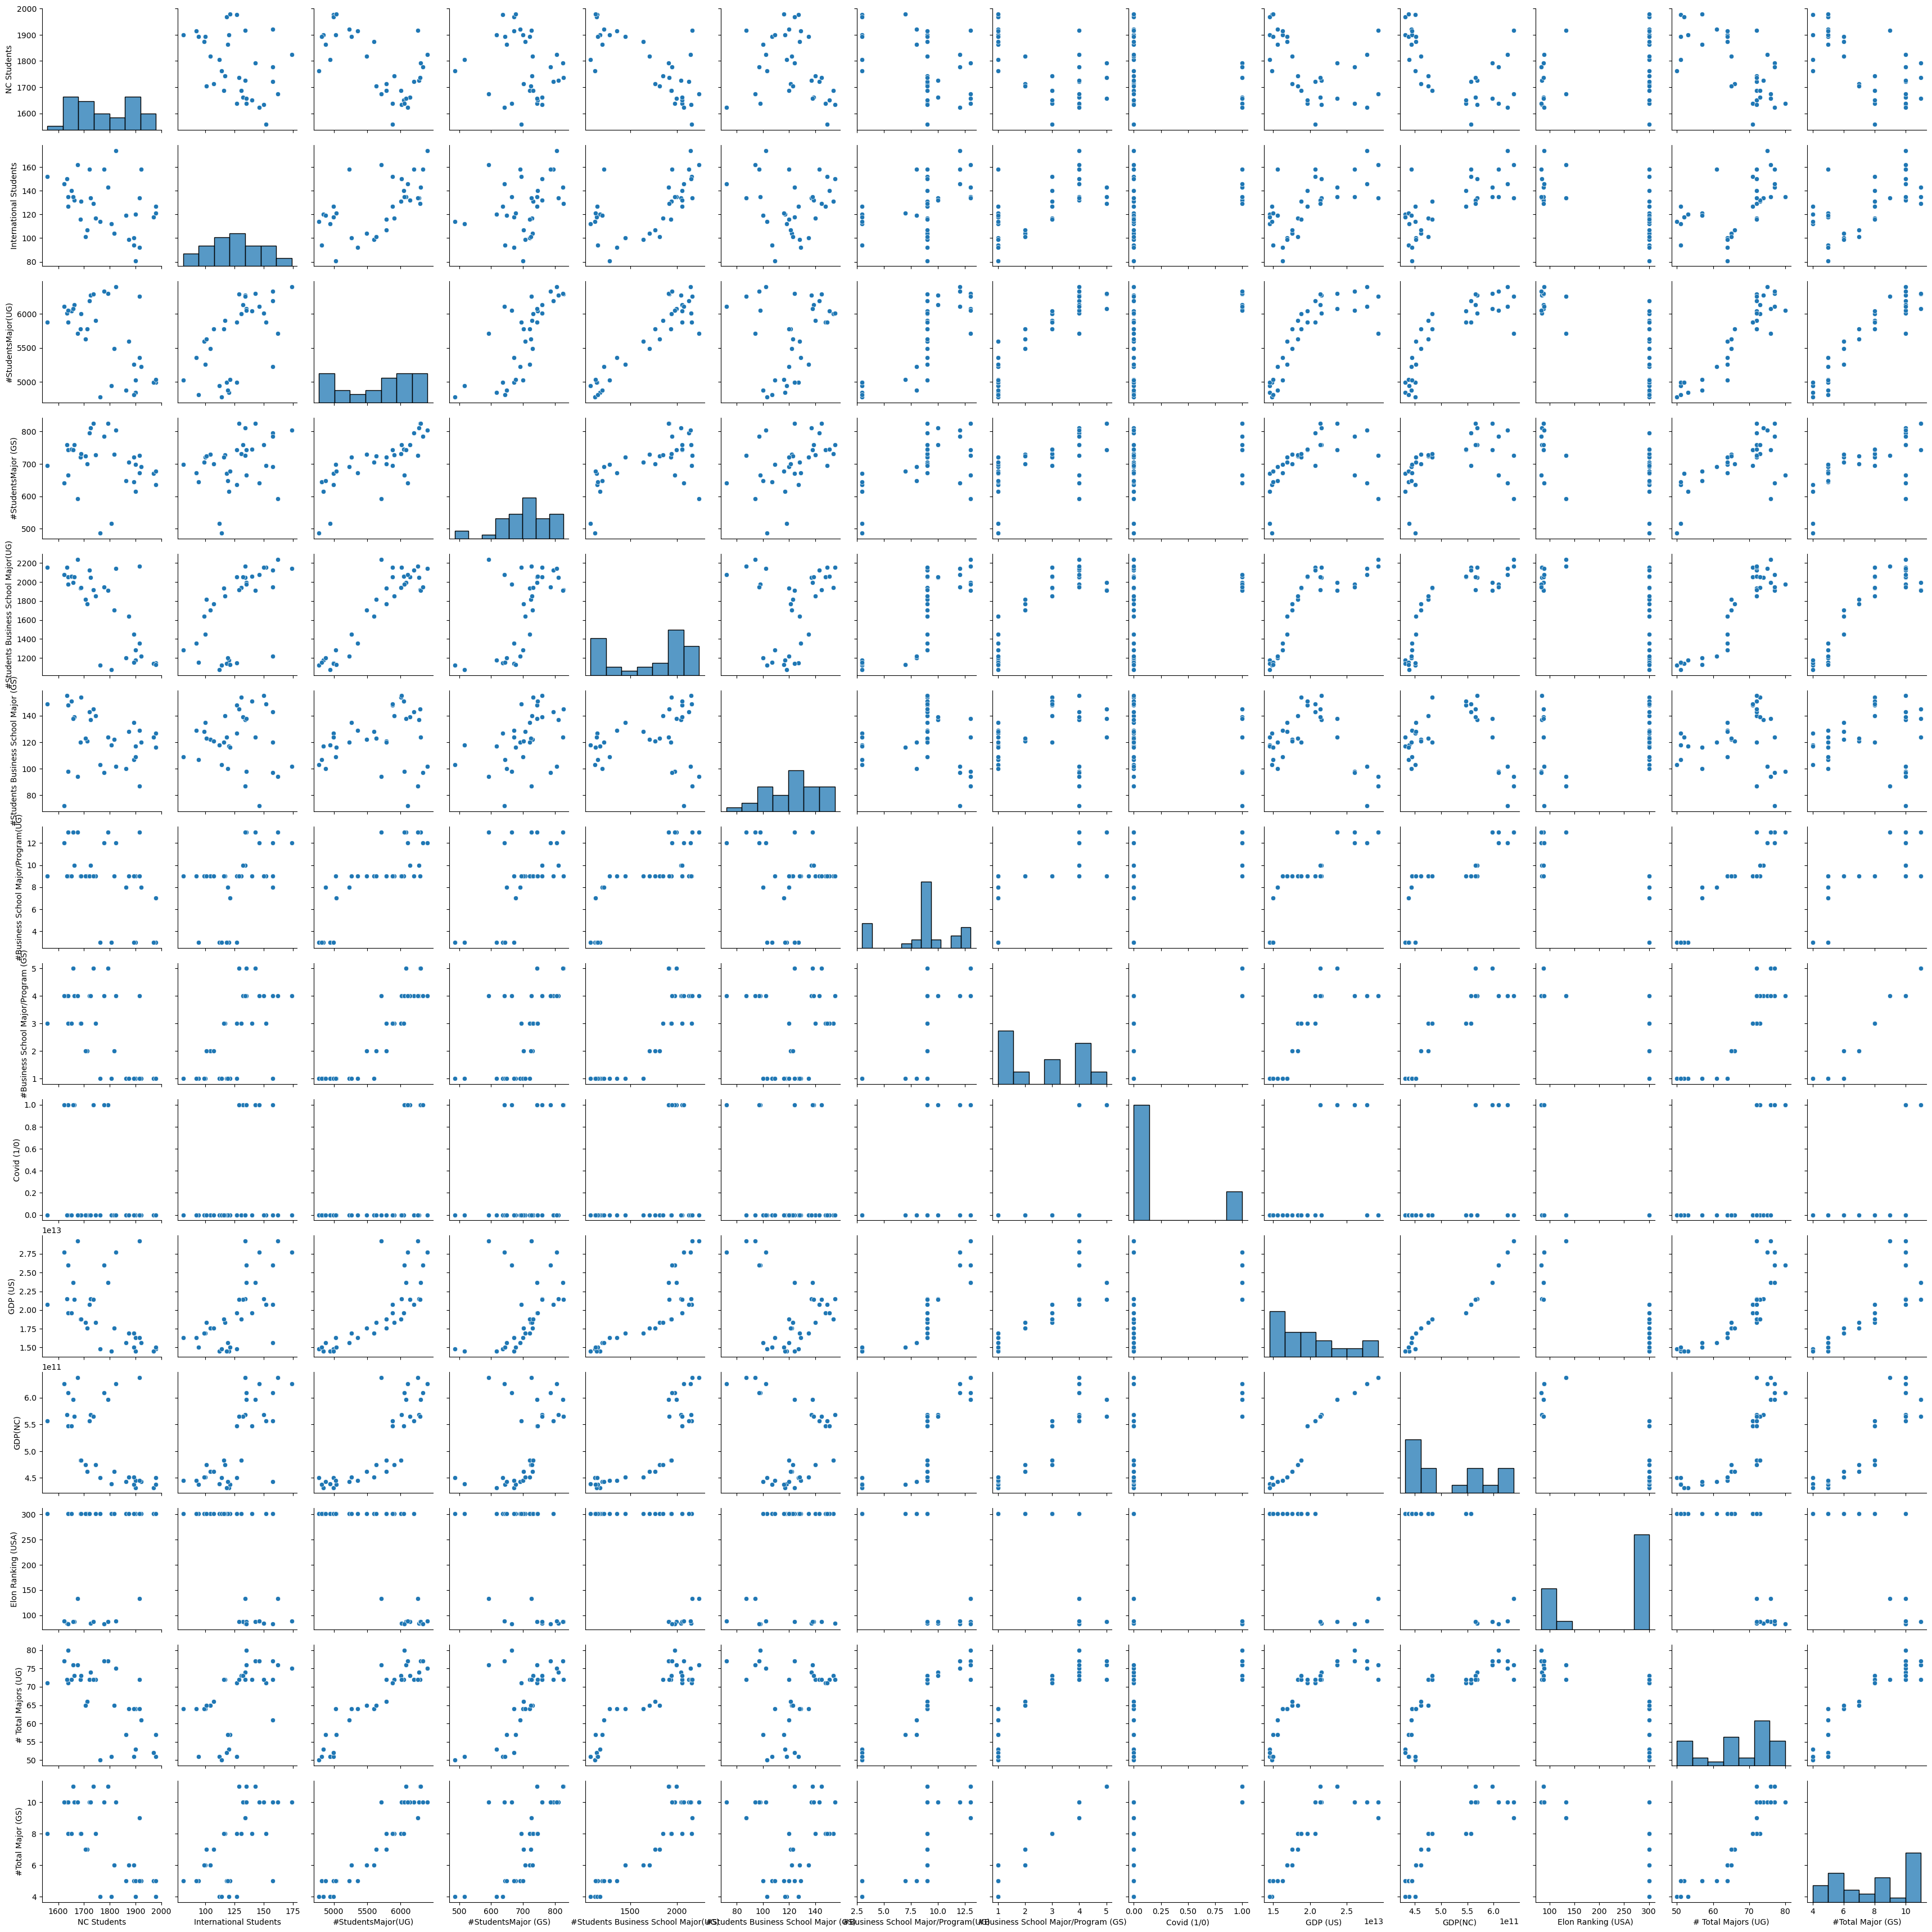

In [4]:
# Exploratory Data Analysis
sns.pairplot(df)
plt.show()

## Data Preprocessing

In [8]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Change column names
df.rename(columns={"Tuition Fees (year) $": "Tuition Fees (year)", "# of Covid Cases": "Covid Cases"}, inplace=True)

print(df.columns.tolist())

# Remove commas from all numeric columns and convert them to float
df = df.replace({',': ''}, regex=True)

# Convert specific columns to float
df['Tuition Fees (year)'] = df['Tuition Fees (year)'].replace(r'[\$,]', '', regex=True).astype(float)
df['Covid Cases'] = df['Covid Cases'].astype(float)
df['GDP (US)'] = df['GDP (US)'].astype(float)
df['GDP(NC)'] = df['GDP(NC)'].astype(float)

# Confirm data types
print(df.dtypes)

['Year', 'NC Students', 'International Students', '#StudentsMajor(UG)', '#StudentsMajor (GS)', '#Students Business School Major(UG)', '#Students Business School Major (GS)', '#Business School Major/Program(UG)', '#Business School Major/Program (GS)', 'Tuition Fees (year)', 'Covid (1/0)', 'Covid Cases', 'GDP (US)', 'GDP(NC)', 'Elon Ranking (USA)', '# Total Majors (UG)', '#Total Major (GS)']
Year                                     object
NC Students                               int64
International Students                    int64
#StudentsMajor(UG)                        int64
#StudentsMajor (GS)                       int64
#Students Business School Major(UG)       int64
#Students Business School Major (GS)      int64
#Business School Major/Program(UG)        int64
#Business School Major/Program (GS)       int64
Tuition Fees (year)                     float64
Covid (1/0)                               int64
Covid Cases                             float64
GDP (US)                       

In [9]:
# Separate features and target variable
target_ug = '#Students Business School Major(UG)'
target_gs = '#Students Business School Major (GS)'

features_ug = [
    '#Business School Major/Program(UG)', 'Tuition Fees (year)', 'Covid (1/0)', 'Covid Cases',
    'GDP (US)', 'GDP(NC)', 'Elon Ranking (USA)', '# Total Majors (UG)'
]

features_gs = [
    '#Business School Major/Program (GS)', 'Tuition Fees (year)', 'Covid (1/0)', 'Covid Cases',
    'GDP (US)', 'GDP(NC)', 'Elon Ranking (USA)', '#Total Major (GS)'
]

X_ug = df[features_ug]
y_ug = df[target_ug]
X_gs = df[features_gs]
y_gs = df[target_gs]

# Split the data into training and testing sets
X_train_ug, X_test_ug, y_train_ug, y_test_ug = train_test_split(X_ug, y_ug, test_size=0.3, random_state=99)
X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(X_gs, y_gs, test_size=0.3, random_state=99)

## Model 1: Random Forest

In [11]:
# Train Random Forest Regressor for undergraduate students
rf_reg_ug = RandomForestRegressor(
    n_estimators=100,  # Number of trees
    max_depth=15,  # Tree depth (adjustable for better performance)
    min_samples_split=2,  # Minimum samples required to split an internal node
    min_samples_leaf=2,  # Minimum samples required in a leaf node
    random_state=99  # Ensures reproducibility
)
rf_reg_ug.fit(X_train_ug, y_train_ug)

# Train Random Forest Regressor for graduate students
rf_reg_gs = RandomForestRegressor(
    n_estimators=50,  # Number of trees
    max_depth=5,  # Tree depth (adjustable for better performance)
    min_samples_split=4,  # Minimum samples required to split an internal node
    min_samples_leaf=2,  # Minimum samples required in a leaf node
    random_state=99  # Ensures reproducibility
)
rf_reg_gs.fit(X_train_gs, y_train_gs)

RandomForestRegressor(max_depth=5, min_samples_leaf=2, min_samples_split=4,
                      n_estimators=50, random_state=99)

## Model 1: Random Forest Evaluation

In [17]:
# Evaluate the models
for model, X_test, y_test, name in zip([rf_reg_ug, rf_reg_gs], [X_test_ug, X_test_gs], [y_test_ug, y_test_gs], ['Undergraduate', 'Graduate']):
    y_pred = model.predict(X_test)
    print(f"\n{name} Enrollment Prediction Metrics:")
    print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
    print(f"R-squared (R2): {r2_score(y_test, y_pred):.2f}")

# Calculate model performance metrics dynamically
mae_ug = mean_absolute_error(y_test_ug, rf_reg_ug.predict(X_test_ug))
mse_ug = mean_squared_error(y_test_ug, rf_reg_ug.predict(X_test_ug))
r2_ug = r2_score(y_test_ug, rf_reg_ug.predict(X_test_ug))

mae_gs = mean_absolute_error(y_test_gs, rf_reg_gs.predict(X_test_gs))
mse_gs = mean_squared_error(y_test_gs, rf_reg_gs.predict(X_test_gs))
r2_gs = r2_score(y_test_gs, rf_reg_gs.predict(X_test_gs))

# Model Performance Table
metrics_data = {
    "Model": ["Undergraduate", "Graduate"],
    "MAE": [f"{mae_ug:.2f}", f"{mae_gs:.2f}"],
    "MSE": [f"{mse_ug:.2f}", f"{mse_gs:.2f}"],
    "R²": [f"{r2_ug:.2f}", f"{r2_gs:.2f}"]
}
metrics_df = pd.DataFrame(metrics_data)
print("\n", metrics_df, "\n")

# Feature Importance Analysis
print("\nFeature Importances for Undergraduate Enrollment:")
for feature, importance in zip(features_ug, rf_reg_ug.feature_importances_):
    print(f"{feature}: {importance:.4f}")

print("\nFeature Importances for Graduate Enrollment:")
for feature, importance in zip(features_gs, rf_reg_gs.feature_importances_):
    print(f"{feature}: {importance:.4f}")

# Feature Importance Table
feature_importance_ug = pd.DataFrame({"Feature": features_ug, "Importance": rf_reg_ug.feature_importances_})
feature_importance_gs = pd.DataFrame({"Feature": features_gs, "Importance": rf_reg_gs.feature_importances_})

print("\nUndergraduate Feature Importance:")
print(feature_importance_ug.sort_values(by="Importance", ascending=False))

print("\nGraduate Feature Importance:")
print(feature_importance_gs.sort_values(by="Importance", ascending=False))


Undergraduate Enrollment Prediction Metrics:
Mean Absolute Error (MAE): 56.92
Mean Squared Error (MSE): 4415.05
R-squared (R2): 0.91

Graduate Enrollment Prediction Metrics:
Mean Absolute Error (MAE): 6.91
Mean Squared Error (MSE): 60.13
R-squared (R2): 0.79

            Model    MAE      MSE    R²
0  Undergraduate  56.92  4415.05  0.91
1       Graduate   6.91    60.13  0.79 


Feature Importances for Undergraduate Enrollment:
#Business School Major/Program(UG): 0.0253
Tuition Fees (year): 0.4938
Covid (1/0): 0.0027
Covid Cases: 0.0013
GDP (US): 0.1615
GDP(NC): 0.1763
Elon Ranking (USA): 0.0024
# Total Majors (UG): 0.1367

Feature Importances for Graduate Enrollment:
#Business School Major/Program (GS): 0.0074
Tuition Fees (year): 0.2380
Covid (1/0): 0.0021
Covid Cases: 0.0162
GDP (US): 0.3349
GDP(NC): 0.3144
Elon Ranking (USA): 0.0014
#Total Major (GS): 0.0856

Undergraduate Feature Importance:
                              Feature  Importance
1                 Tuition Fees (year)   

## Model 1: Deployment

In [30]:
# Step 7: Predict for new data
def predict_new_data(new_df):
    # Ensure the columns are in the correct order
    new_df_ug = new_df[features_ug]  # Select only the UG features
    new_df_gs = new_df[features_gs]  # Select only the GS features

    # Make predictions for Undergraduate and Graduate enrollment
    new_predictions_ug = rf_reg_ug.predict(new_df_ug)
    new_predictions_gs = rf_reg_gs.predict(new_df_gs)

    future_semesters = ["Spring 2025", "Fall 2025", "Spring 2026", "Fall 2026", "Spring 2027"]

    print("\nPredictions for New Data:\n")
    for i, row in new_df.iterrows():
        print(future_semesters[i])
        print(f"Elon Ranking: {row['Elon Ranking (USA)']}, Tuition Fees: {row['Tuition Fees (year)']},\n"
              f"GDP (US): {row['GDP (US)']}, GDP (NC): {row['GDP(NC)']},\n"
              f"Covid Cases: {row['Covid Cases']}, Covid Indicator: {row['Covid (1/0)']}\n"
              f"Predicted UG Enrollment: {new_predictions_ug[i]:.0f}, Predicted GS Enrollment: {new_predictions_gs[i]:.0f}\n")
              
# Example usage: Load new data for the next 5 semesters
new_data = {
    'Elon Ranking (USA)': [130, 130, 127, 125, 123],  # Improved rankings over time
    'Tuition Fees (year)': [23800, 23800, 24400, 24400, 25500],  # Gradually increasing tuition fees
    'GDP (US)': [29500000000000, 29500000000000, 31500000000000, 31500000000000, 32800000000000],  # Steady growth in GDP values (US)
    'GDP(NC)': [646000000000, 646000000000, 675000000000, 675000000000, 700000000000],  # Steady growth in GDP values (NC)
    'Covid Cases': [0, 0, 0, 0, 0],  # No Covid cases projected for these semesters
    'Covid (1/0)': [0, 0, 0, 0, 0],  # Covid indicator remains 0 (no cases)
    '#Business School Major/Program(UG)': [13, 13, 14, 14, 15],  # Slight increase in UG enrollment in business programs
    '#Business School Major/Program (GS)': [4, 4, 5, 5, 5],  # Gradual increase in GS enrollment in business programs
    '# Total Majors (UG)': [75, 75, 76, 76, 77],  # Incremental growth in total UG majors
    '#Total Major (GS)': [10, 10, 11, 11, 11],  # Incremental growth in total GS majors
}

# Convert the new data into a DataFrame
new_df = pd.DataFrame(new_data)

# Call the function to make predictions
predict_new_data(new_df)



Predictions for New Data:

Spring 2025
Elon Ranking: 130, Tuition Fees: 23800,
GDP (US): 29500000000000, GDP (NC): 646000000000,
Covid Cases: 0, Covid Indicator: 0
Predicted UG Enrollment: 2143, Predicted GS Enrollment: 96

Fall 2025
Elon Ranking: 130, Tuition Fees: 23800,
GDP (US): 29500000000000, GDP (NC): 646000000000,
Covid Cases: 0, Covid Indicator: 0
Predicted UG Enrollment: 2143, Predicted GS Enrollment: 96

Spring 2026
Elon Ranking: 127, Tuition Fees: 24400,
GDP (US): 31500000000000, GDP (NC): 675000000000,
Covid Cases: 0, Covid Indicator: 0
Predicted UG Enrollment: 2143, Predicted GS Enrollment: 96

Fall 2026
Elon Ranking: 125, Tuition Fees: 24400,
GDP (US): 31500000000000, GDP (NC): 675000000000,
Covid Cases: 0, Covid Indicator: 0
Predicted UG Enrollment: 2143, Predicted GS Enrollment: 96

Spring 2027
Elon Ranking: 123, Tuition Fees: 25500,
GDP (US): 32800000000000, GDP (NC): 700000000000,
Covid Cases: 0, Covid Indicator: 0
Predicted UG Enrollment: 2139, Predicted GS Enrollm

# Model 1: Graphical Summaries

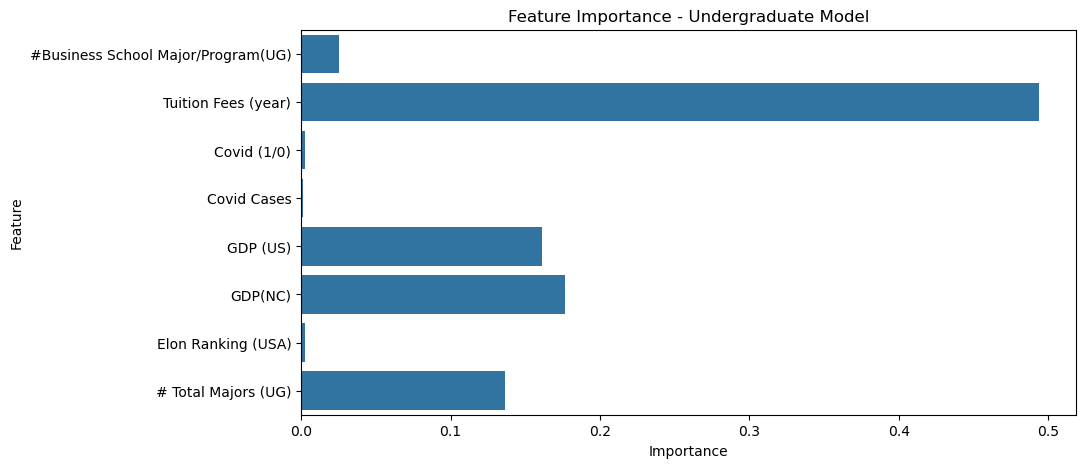

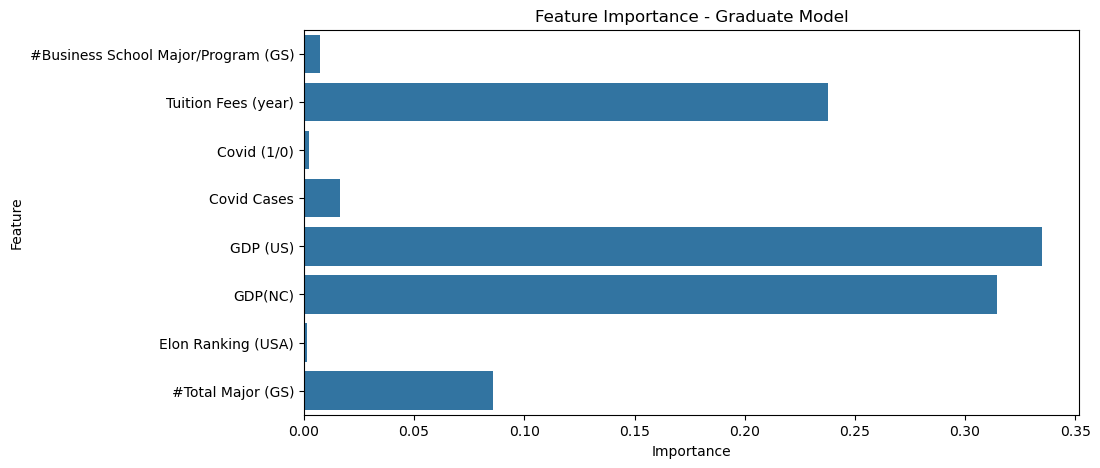

In [33]:
## 1. Feature Importance Visualization

# Plot feature importance for Undergraduate Model
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance_ug["Importance"], y=feature_importance_ug["Feature"])
plt.title("Feature Importance - Undergraduate Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Plot feature importance for Graduate Model
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance_gs["Importance"], y=feature_importance_gs["Feature"])
plt.title("Feature Importance - Graduate Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

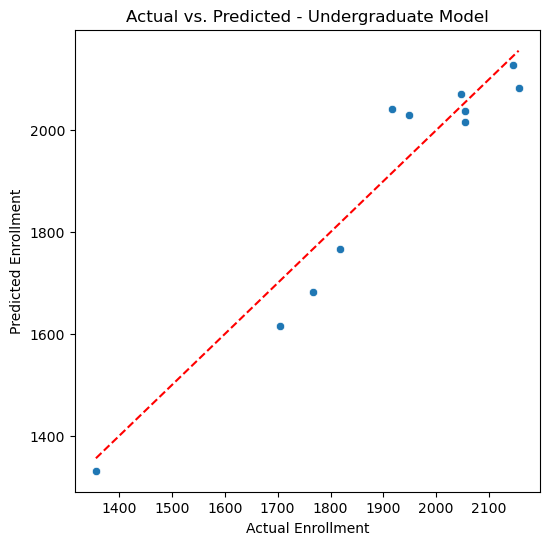

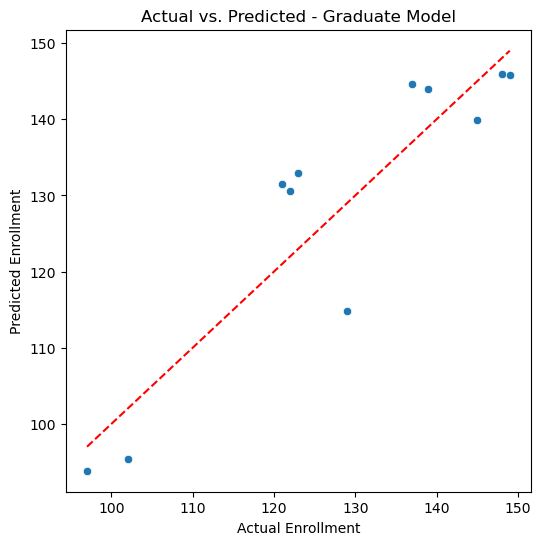

In [35]:
## 2. Actual vs. Predicted Scatter Plot

# Scatter plot for Undergraduate Model
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test_ug, y=rf_reg_ug.predict(X_test_ug))
plt.plot([min(y_test_ug), max(y_test_ug)], [min(y_test_ug), max(y_test_ug)], color='red', linestyle='--')
plt.title("Actual vs. Predicted - Undergraduate Model")
plt.xlabel("Actual Enrollment")
plt.ylabel("Predicted Enrollment")
plt.show()

# Scatter plot for Graduate Model
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test_gs, y=rf_reg_gs.predict(X_test_gs))
plt.plot([min(y_test_gs), max(y_test_gs)], [min(y_test_gs), max(y_test_gs)], color='red', linestyle='--')
plt.title("Actual vs. Predicted - Graduate Model")
plt.xlabel("Actual Enrollment")
plt.ylabel("Predicted Enrollment")
plt.show()

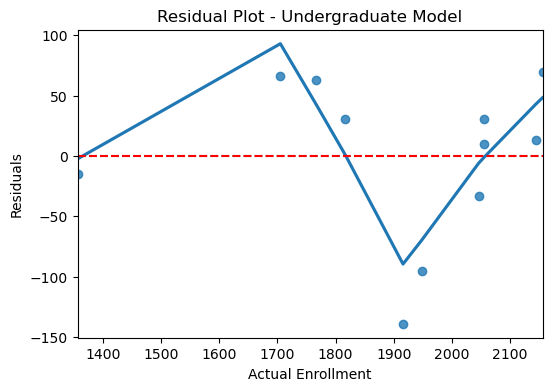

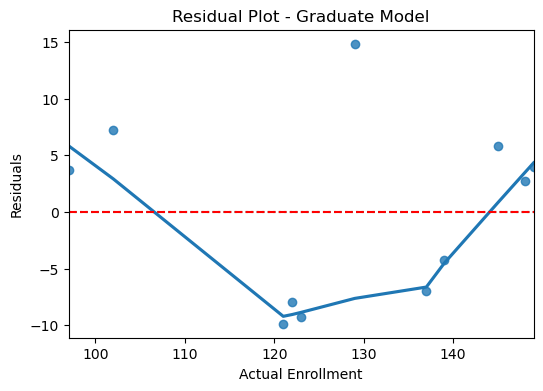

In [37]:
## 3. Residual Plot to Check Model Fit

# Residual plot for Undergraduate Model
plt.figure(figsize=(6,4))
sns.residplot(x=y_test_ug, y=y_test_ug - rf_reg_ug.predict(X_test_ug), lowess=True)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot - Undergraduate Model")
plt.xlabel("Actual Enrollment")
plt.ylabel("Residuals")
plt.show()

# Residual plot for Graduate Model
plt.figure(figsize=(6,4))
sns.residplot(x=y_test_gs, y=y_test_gs - rf_reg_gs.predict(X_test_gs), lowess=True)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot - Graduate Model")
plt.xlabel("Actual Enrollment")
plt.ylabel("Residuals")
plt.show()

## Model 2: MLR

   #Students Business School Major(UG)  #Students Business School Major (GS)  \
0                                 1077                                   118   
1                                 1121                                   103   
2                                 1148                                   127   
3                                 1175                                   117   
4                                 1141                                   124   

   #Business School Major/Program (GS)  #Business School Major/Program(UG)  \
0                                    1                                   3   
1                                    1                                   3   
2                                    1                                   3   
3                                    1                                   3   
4                                    1                                   3   

   NC Students  International Students  Covid Case

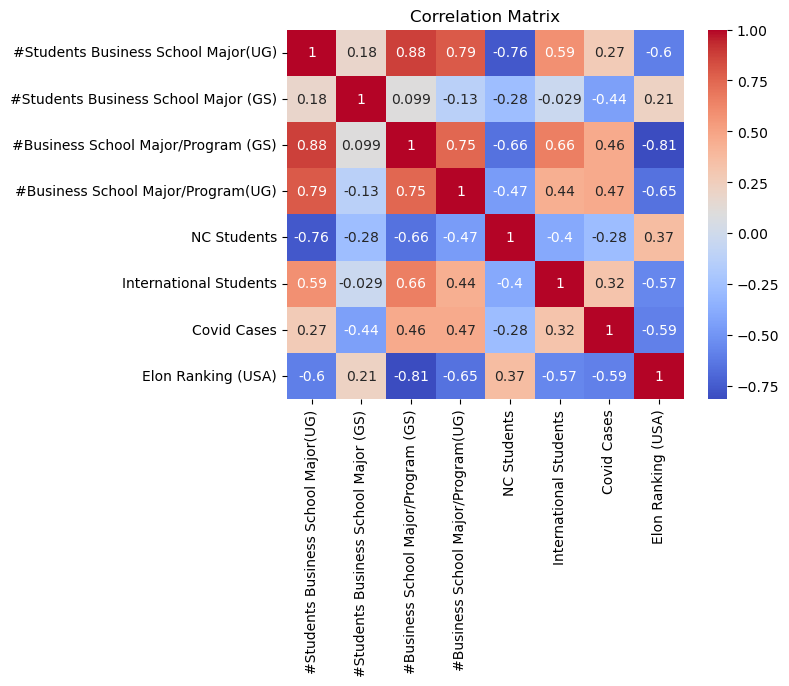

In [11]:
# Check correlations
selected_columns=df.loc[:,['#Students Business School Major(UG)','#Students Business School Major (GS)', '#Business School Major/Program (GS)','#Business School Major/Program(UG)','NC Students','International Students','Covid Cases','Elon Ranking (USA)']]
print(selected_columns.head())

sns.heatmap(selected_columns.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [13]:
print(df.columns.tolist())

['Year', 'NC Students', 'International Students', '#StudentsMajor(UG)', '#StudentsMajor (GS)', '#Students Business School Major(UG)', '#Students Business School Major (GS)', '#Business School Major/Program(UG)', '#Business School Major/Program (GS)', 'Tuition Fees (year)', 'Covid (1/0)', 'Covid Cases', 'GDP (US)', 'GDP(NC)', 'Elon Ranking (USA)', '# Total Majors (UG)', '#Total Major (GS)']


In [15]:
# Feature selection
MLR_features = ['NC Students','International Students','#Business School Major/Program(UG)','#Business School Major/Program (GS)','Covid Cases','Elon Ranking (USA)']

target_ug = '#Students Business School Major(UG)'
target_gs = '#Students Business School Major (GS)'

X_ug = df[MLR_features]
y_ug = df[target_ug]
X_gs = df[MLR_features]
y_gs = df[target_gs]

# Split the data into training and testing sets
X_train_ug, X_test_ug, y_train_ug, y_test_ug = train_test_split(X_ug, y_ug, test_size=0.3, random_state=99)
X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(X_gs, y_gs, test_size=0.3, random_state=99)



# Modeling 
# Initialize the model
model_ug = LinearRegression()
model_gs = LinearRegression()

# Train the model
model_ug.fit(X_train_ug[MLR_features], y_train_ug)
model_gs.fit(X_train_gs[MLR_features], y_train_gs)

# Get model parameters
print('Undergraduate Intercept:', model_ug.intercept_)
print(pd.DataFrame({'Predictor': X_ug.columns, 'coefficient': model_ug.coef_}))

print('\n\n')

print('Graduate Intercept:', model_gs.intercept_)
print(pd.DataFrame({'Predictor': X_gs.columns, 'coefficient': model_gs.coef_}))



Undergraduate Intercept: 2301.522133019653
                             Predictor  coefficient
0                          NC Students    -0.901713
1               International Students     0.594061
2   #Business School Major/Program(UG)    44.456895
3  #Business School Major/Program (GS)   169.966924
4                          Covid Cases    -0.000003
5                   Elon Ranking (USA)     0.537008



Graduate Intercept: 144.58185868151975
                             Predictor   coefficient
0                          NC Students -3.140362e-02
1               International Students -3.521236e-02
2   #Business School Major/Program(UG) -1.355057e+00
3  #Business School Major/Program (GS)  1.039281e+01
4                          Covid Cases -3.248948e-07
5                   Elon Ranking (USA)  1.083634e-01


### <span style = 'color: red'>Equation below needs to be updated as I have updated the MLR to predict both Graduate and Undergraduate</span>

MLR Equations:
For Undergraduate Enrollment Prediction:

$$Y=2301.52−0.90(X1)+0.59(X2)+44.46(X3)+169.97(X4)−0.000003(X5)+0.54(X6)$$

For Graduate Enrollment Prediction:
$$Y=144.58−0.031(X1)−0.035(X2)−1.36(X3)+10.39(X4)−0.0000003(X5+0.108(X6)$$

$$ X1 = NC Students $$ 
$$ X2 = International Students $$ 
$$ X3 = Number of Business School Major/Program (UG) $$
$$ X4 = Number of Business Major/Program (GS)$$
$$ X4 = Number of COVID Cases  $$
$$ X5 = Elon Ranking (USA) $$

## Model 2: - Performance Evaluations

In [17]:
# Evaluation
# Predictions
y_pred_ug = model_ug.predict(X_test_ug)
y_pred_gs = model_gs.predict(X_test_gs)
# Metrics
mae_mlr_gs = mean_absolute_error(y_test_gs, y_pred_gs)
mae_mlr_ug = mean_absolute_error(y_test_ug, y_pred_ug)
mse_mlr_gs = mean_squared_error(y_test_gs, y_pred_gs)
mse_mlr_ug = mean_squared_error(y_test_ug, y_pred_ug)
r2_ug = r2_score(y_test_ug, y_pred_ug)
r2_gs = r2_score(y_test_gs, y_pred_gs)


print('MLR_Graduate Performance:')
print(pd.DataFrame({"MAE": [mae_mlr_gs], "RSE": [mse_mlr_gs], "R²": [r2_gs]}, index = ['Graduate']))

print('\n\n')

print('MLR_Undergraduate Performance:')
print(pd.DataFrame({"MAE": [mae_mlr_ug], "RSE": [mse_mlr_ug], "R²": [r2_ug]}, index = ['Under_Graduate']))




MLR_Graduate Performance:
                MAE         RSE        R²
Graduate  10.878232  139.689069  0.500875



MLR_Undergraduate Performance:
                      MAE          RSE        R²
Under_Graduate  81.523018  9162.678005  0.818603


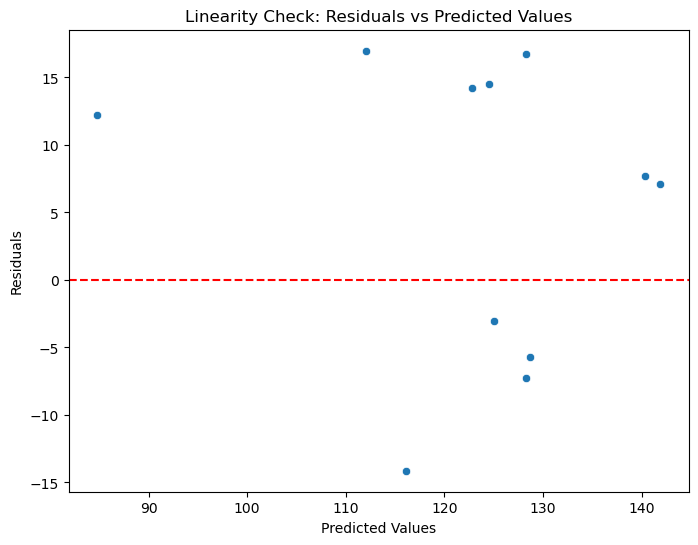

In [19]:
# Residuals
# 1.Linearity Check
residuals_gs = y_test_gs - y_pred_gs

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_gs, y=residuals_gs)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Linearity Check: Residuals vs Predicted Values")
plt.show()

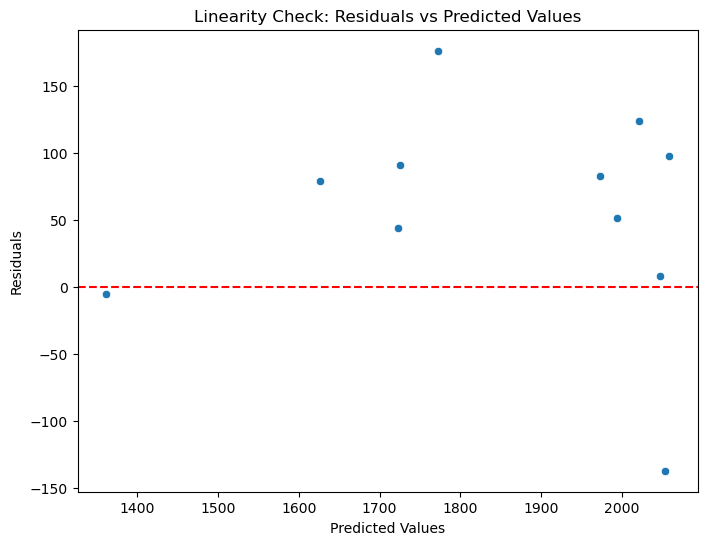

In [21]:
# Residuals
# 1.Linearity Check
residuals_ug = y_test_ug - y_pred_ug

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_ug, y=residuals_ug)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Linearity Check: Residuals vs Predicted Values")
plt.show()

In [23]:
# 2. Independence (Durbin-Watson test using statsmodels) within 2 is good
X_train_sm = sm.add_constant(X_train_ug)
ols_model_ug = sm.OLS(y_train_ug, X_train_sm).fit()
dw_stat = sm.stats.stattools.durbin_watson(ols_model_ug.resid)
print("Durbin-Watson Statistic for Undergraduate:", dw_stat)

Durbin-Watson Statistic for Undergraduate: 2.020656908953219


In [25]:
# 2. Independence (Durbin-Watson test using statsmodels) within 2 is good
X_train_sm = sm.add_constant(X_train_gs)
ols_model_gs = sm.OLS(y_train_gs, X_train_sm).fit()
dw_stat = sm.stats.stattools.durbin_watson(ols_model_gs.resid)
print("Durbin-Watson Statistic for Graduate:", dw_stat)

Durbin-Watson Statistic for Graduate: 2.3370255372447692


In [27]:
# 3. Homoscedasticity (Breusch-Pagan Test)
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(ols_model_ug.resid, X_train_sm)
print("Breusch-Pagan Test p-value for Undergraduate:", bp_test[1])  # Look for p > 0.05 for homoscedasticity

Breusch-Pagan Test p-value for Undergraduate: 0.45086431780775693


In [29]:
# 3. Homoscedasticity (Breusch-Pagan Test)
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(ols_model_gs.resid, X_train_sm)
print("Breusch-Pagan Test p-value for Graduate:", bp_test[1])  # Look for p > 0.05 for homoscedasticity

Breusch-Pagan Test p-value for Graduate: 0.014113970378126195


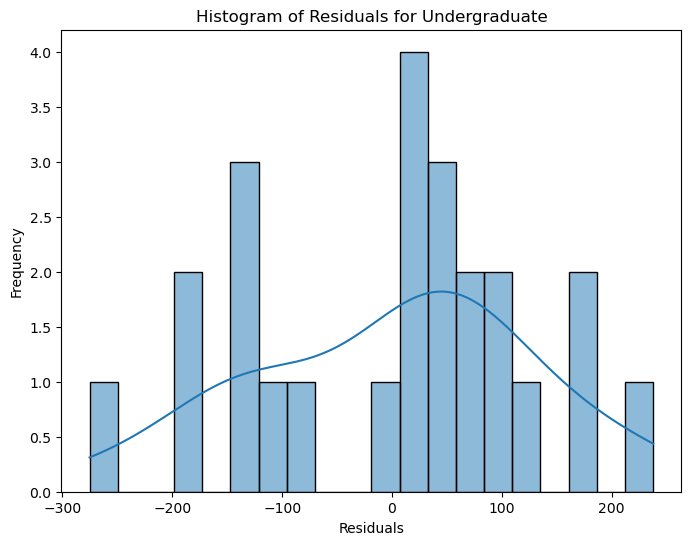

NameError: name 'ols_model' is not defined

In [31]:
# 4. Normality (Histogram & QQ-Plot)
plt.figure(figsize=(8, 6))
sns.histplot(ols_model_ug.resid, kde=True, bins=20)
plt.title("Histogram of Residuals for Undergraduate")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

sm.qqplot(ols_model.resid, line="s")
plt.title("QQ Plot of Residuals")
plt.show()

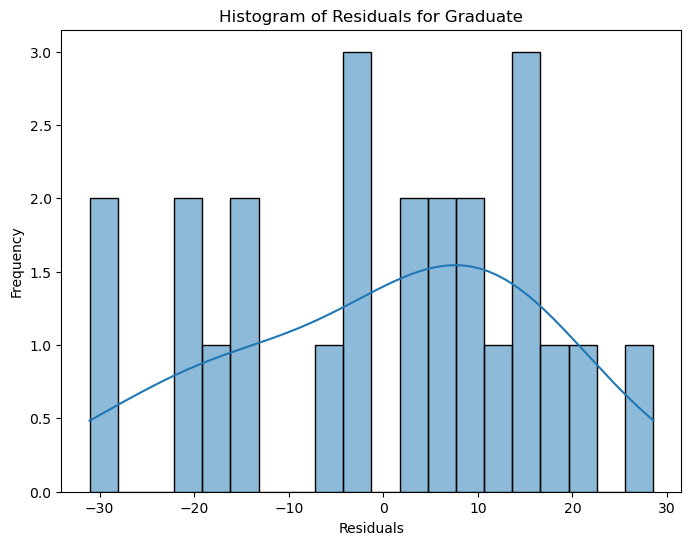

NameError: name 'ols_model' is not defined

In [33]:
# 4. Normality (Histogram & QQ-Plot)
plt.figure(figsize=(8, 6))
sns.histplot(ols_model_gs.resid, kde=True, bins=20)
plt.title("Histogram of Residuals for Graduate")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

sm.qqplot(ols_model.resid, line="s")
plt.title("QQ Plot of Residuals")
plt.show()

In [35]:
# 5. Multicollinearity (Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_ug.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_ug.values, i) for i in range(X_train_ug.shape[1])]
print("\nVariance Inflation Factor (VIF):\n", vif_data)

# Interpretation of VIF:
# - VIF = 1: No multicollinearity.
# - VIF < 5: Acceptable multicollinearity.
# - VIF > 5: Problematic multicollinearity.


Variance Inflation Factor (VIF):
                                Feature        VIF
0                          NC Students  81.294225
1               International Students  64.223533
2   #Business School Major/Program(UG)  19.415211
3  #Business School Major/Program (GS)  19.240512
4                          Covid Cases   2.119268
5                   Elon Ranking (USA)  25.181816
